In [217]:
#chargement des bibliothèques
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
train_file_path = 'predict_loan_train.csv'
train_data = pd.read_csv(train_file_path)

In [206]:
train_data.head(20)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,1.0,Self-employed,Other,12.0,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,2.0,Employed,Debt consolidation,17.0,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,1.0,Employed,Debt consolidation,14.0,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,1.0,Employed,Debt consolidation,25.0,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,1.0,Employed,Other,15.0,1.0
5,5,44940.30,0.058,653,12159.92,12.24,Male,Single,0.0,Employed,Other,15.0,1.0
6,6,61574.16,0.042,696,16907.71,13.52,Other,Single,1.0,Self-employed,Debt consolidation,14.0,1.0
7,7,45953.31,0.100,654,10111.62,12.82,Female,Married,1.0,Employed,Home,15.0,1.0
8,8,30592.29,0.132,713,7522.36,9.48,Male,Married,0.0,Employed,Education,14.0,1.0
9,9,17342.45,0.121,548,9653.48,16.04,Female,Married,0.0,Self-employed,Vacation,25.0,1.0


In [5]:
train_data.shape

(593994, 13)

In [14]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [15]:
train_data.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442235,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [19]:
train_data.isna().sum()

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

### ANALYSE DES VARIABLES QUANTITATIVES

#### BOXPLOT 
pour etudier la dispersion des données et identifier les outliers afin de voir si une standardisation sera necessaire

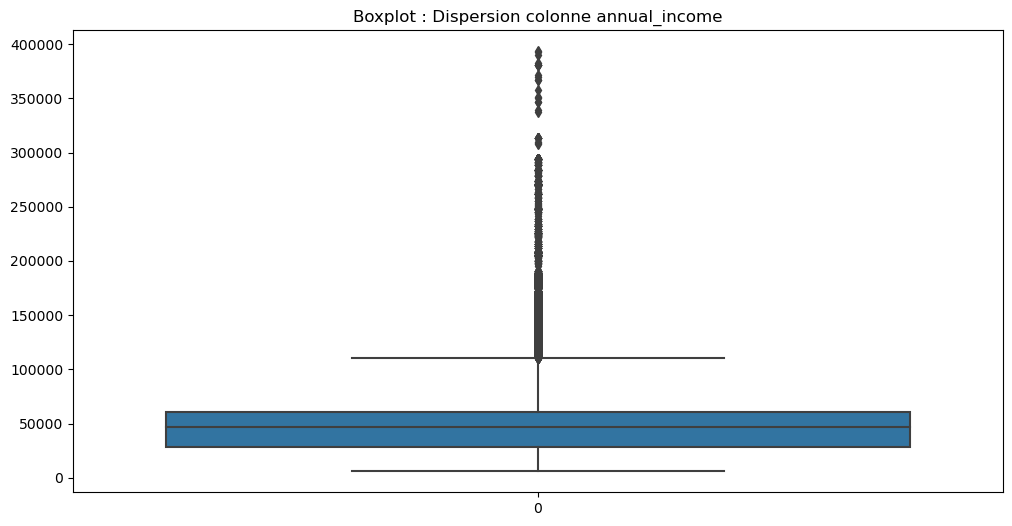

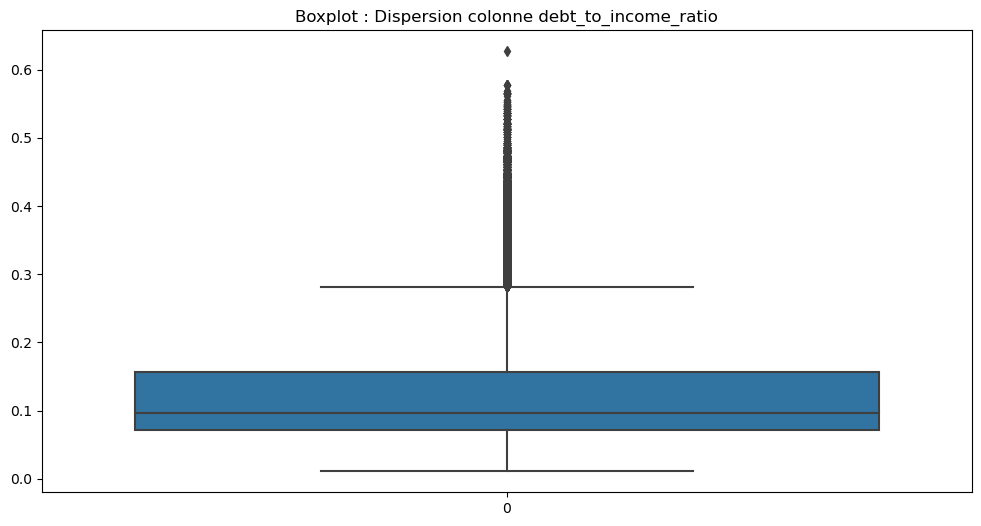

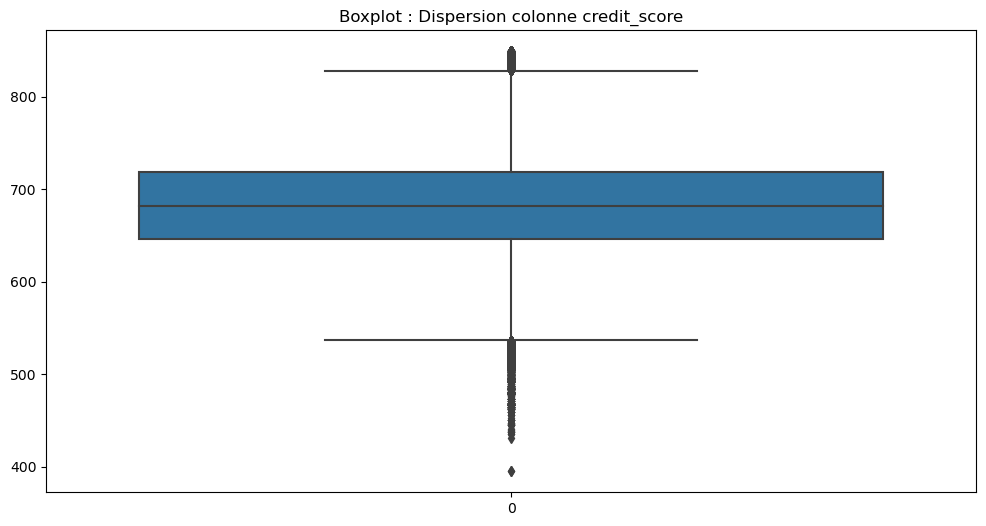

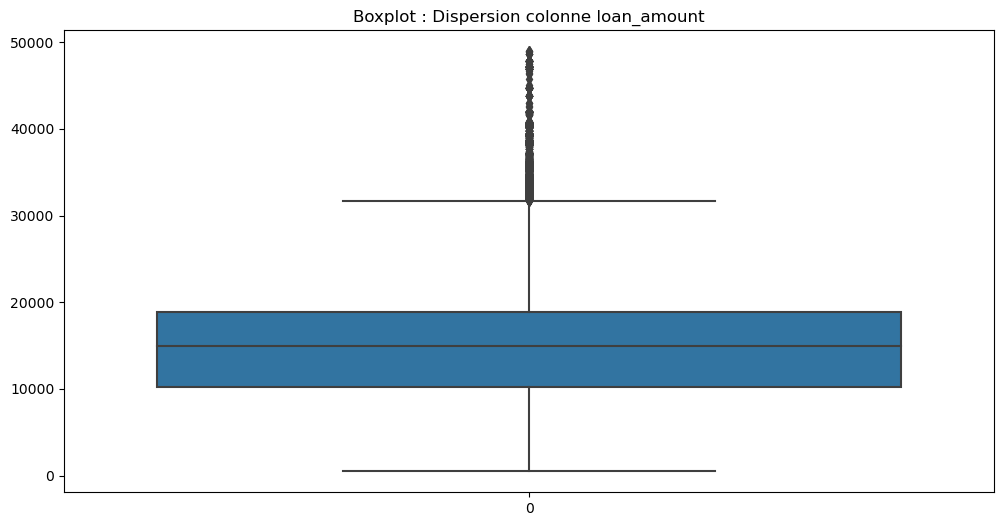

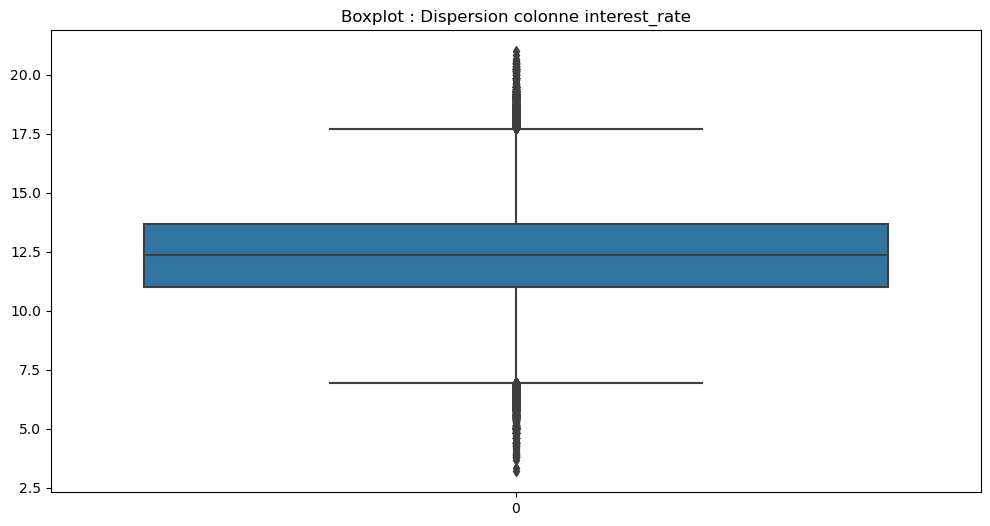

In [43]:
#selectionne toutes les colonnes numériques
colonnes_numeriques = train_data.select_dtypes(include = ['float64', 'int64']).columns.delete([0, 6])

for colonne in colonnes_numeriques:
    plt.figure(figsize =(12, 6))
    sns.boxplot(data = train_data[colonne])
    plt.title(f'Boxplot : Dispersion colonne {colonne}')
    plt.show()

- on observe dans chaque boxplot qu'on retrouve beaucoup de valeurs en dehors des moustaches (des outliers ou des éléments pertinents à etudier?)

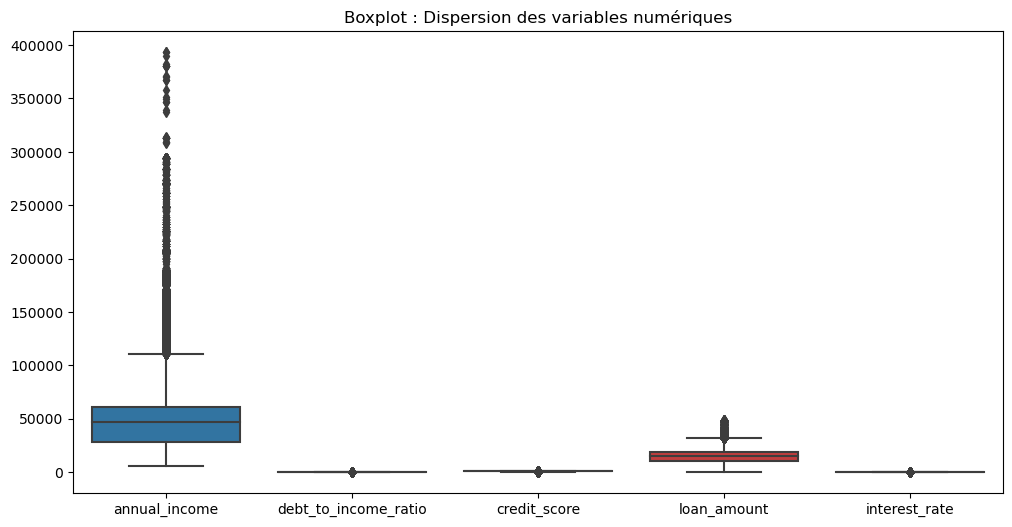

In [45]:
colonnes_numeriques = train_data.select_dtypes(include = ['float64', 'int64']).columns.delete([0, 6])
#on retire la première et derniere colonne qui correspondent à la colonne Id et à la colonne de la variable cible

plt.figure(figsize =(12, 6))
sns.boxplot(data = train_data[colonnes_numeriques])
plt.title(f'Boxplot : Dispersion des variables numériques')
plt.show()

- On note que les echelles des variables sont très différentes

#### HISTOGRAMME pour etudier la distribution

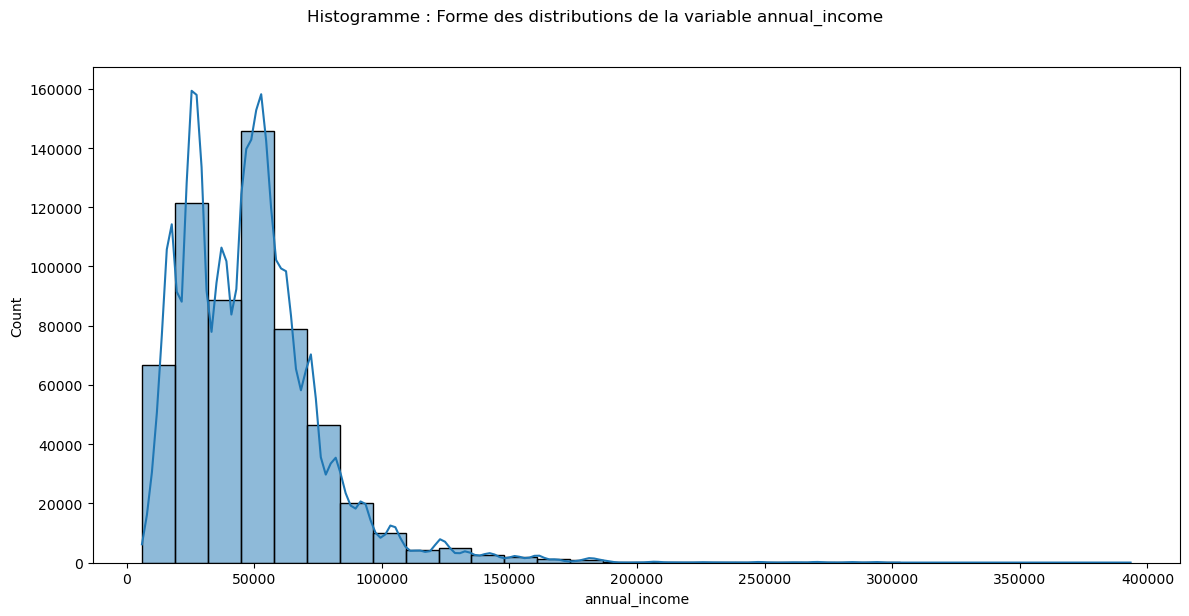

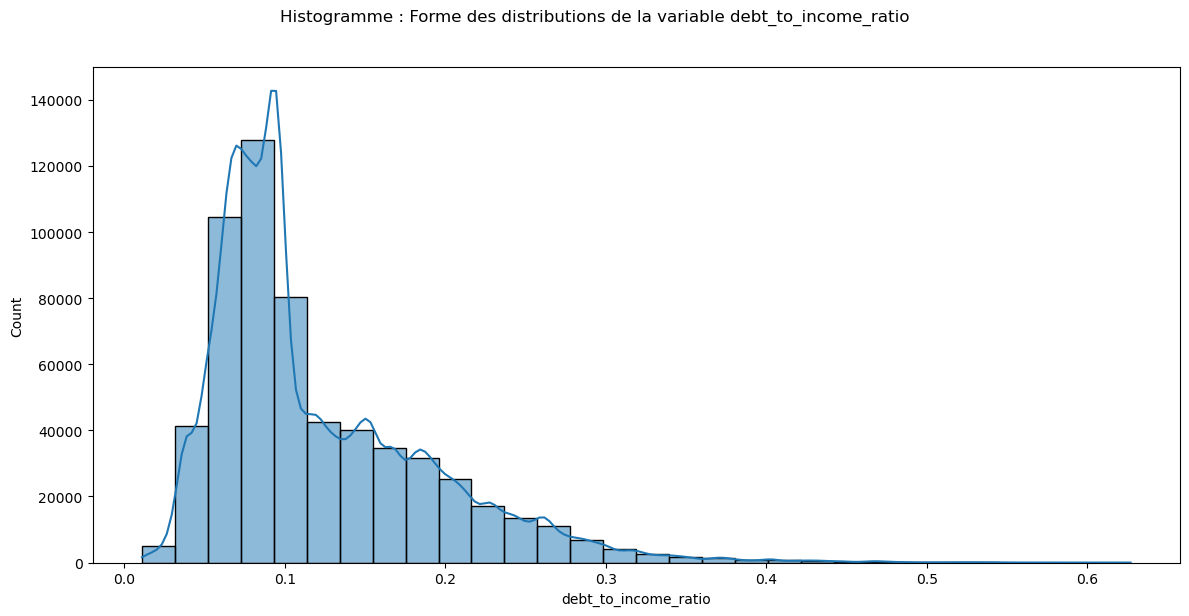

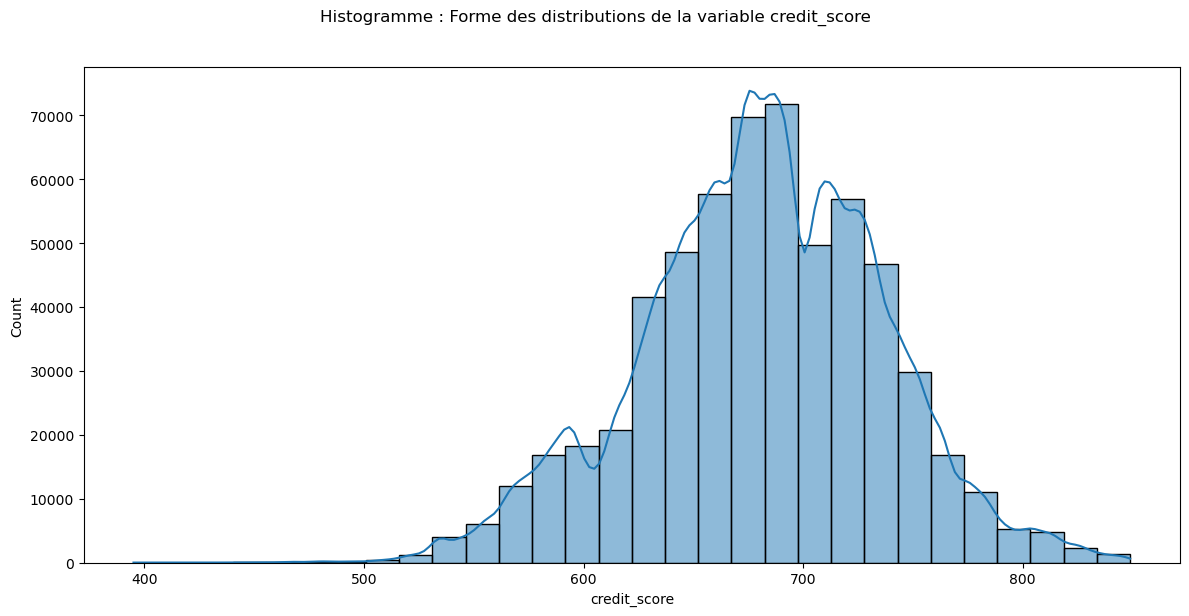

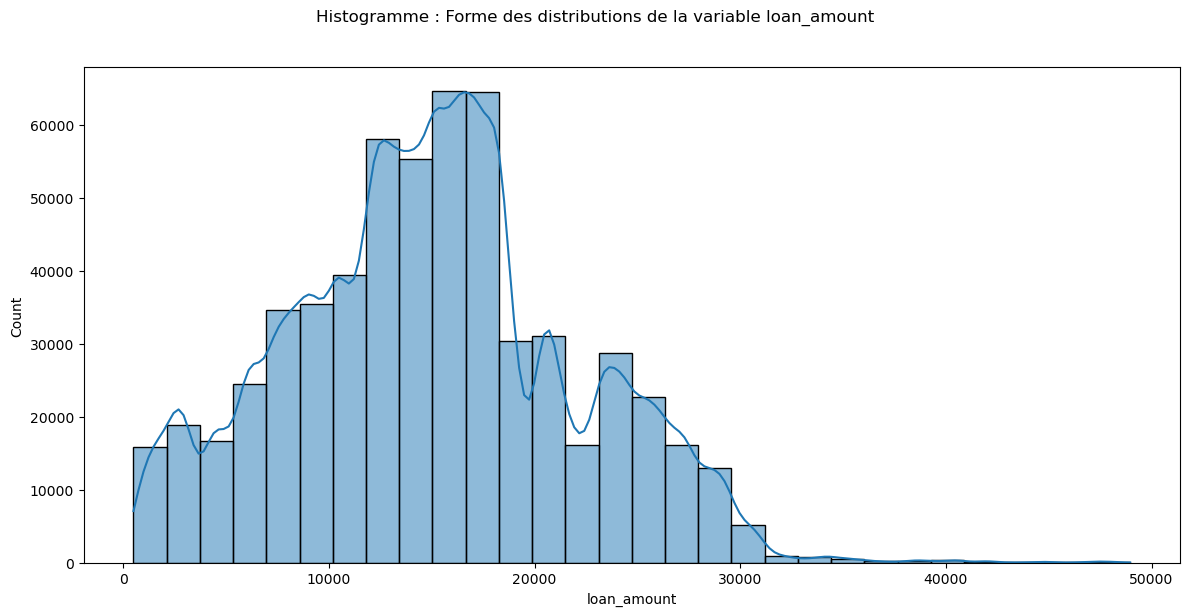

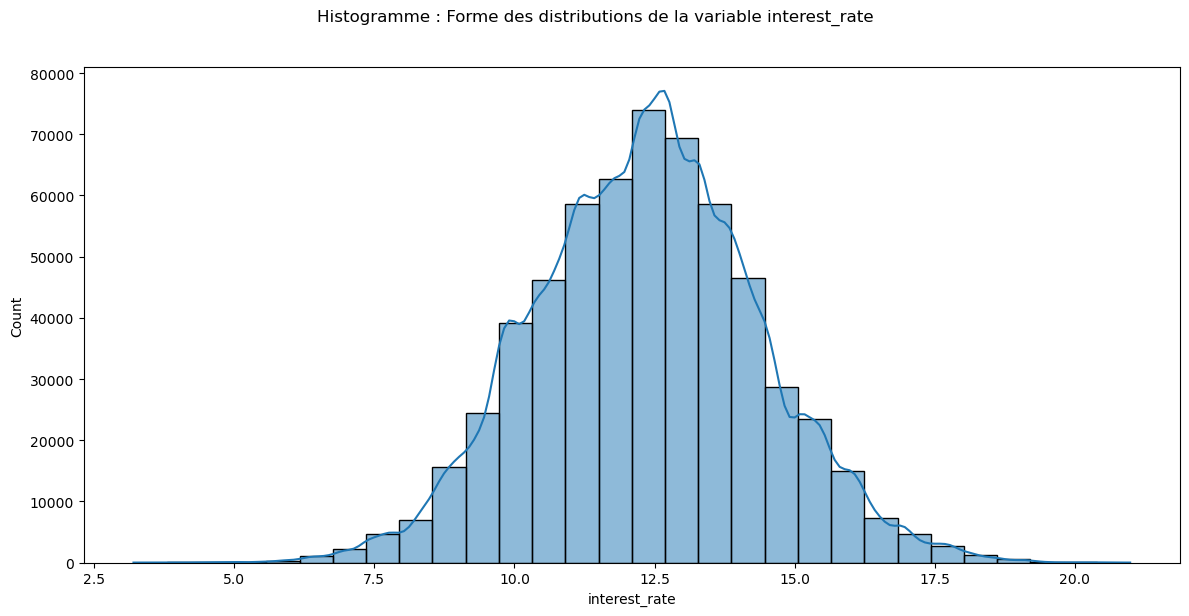

In [57]:
colonnes_numeriques = train_data.select_dtypes(include = ['float64', 'int64']).columns.delete([0, 6])

for colonne in colonnes_numeriques:
    plt.figure(figsize =(12, 6))
    sns.histplot(train_data[colonne], bins=30, kde =True)
    plt.suptitle(f'Histogramme : Forme des distributions de la variable {colonne}', y=1.02)
    plt.tight_layout()
    plt.show()

#### Ce qui ressort de ces observations :
- Les échelles des différentes variables sont très différentes
- les distributions des variables quantitatives sont pour la plupart sont gaussiennes exceptions faites des colonnes credit_score et debt_to_income_ratio 

### ANALYSE DES VARIABLES QUALITATIVES

In [85]:
colonnes_qualitatives = train_data.select_dtypes(['object']).columns
colonnes_qualitatives = colonnes_qualitatives.union(['loan_paid_back'])

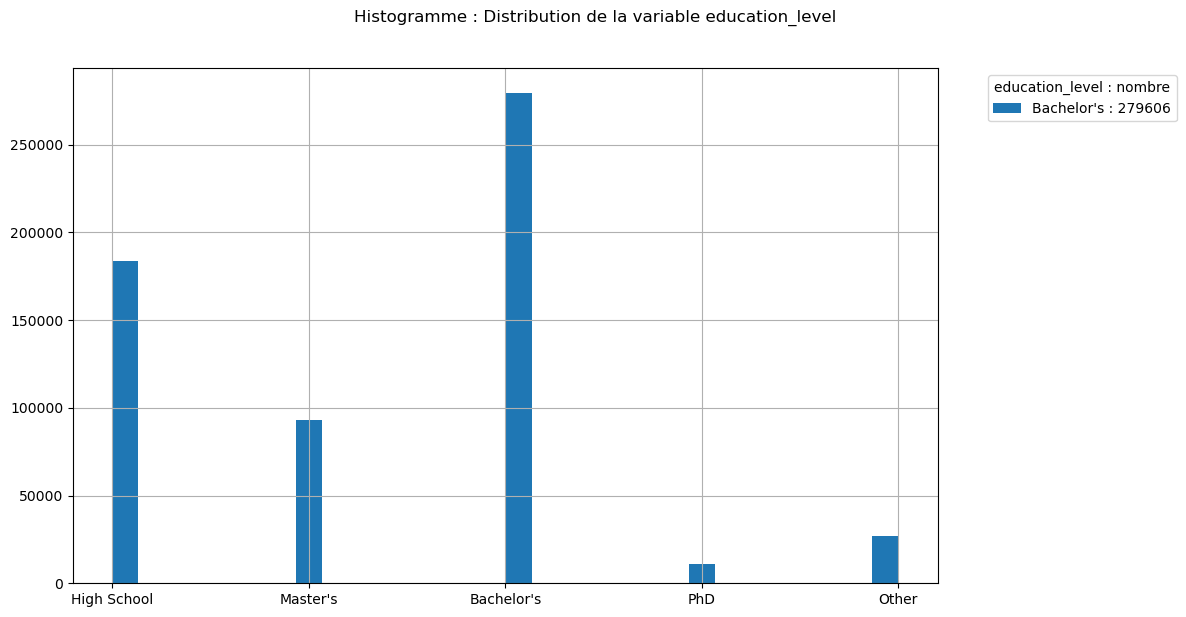

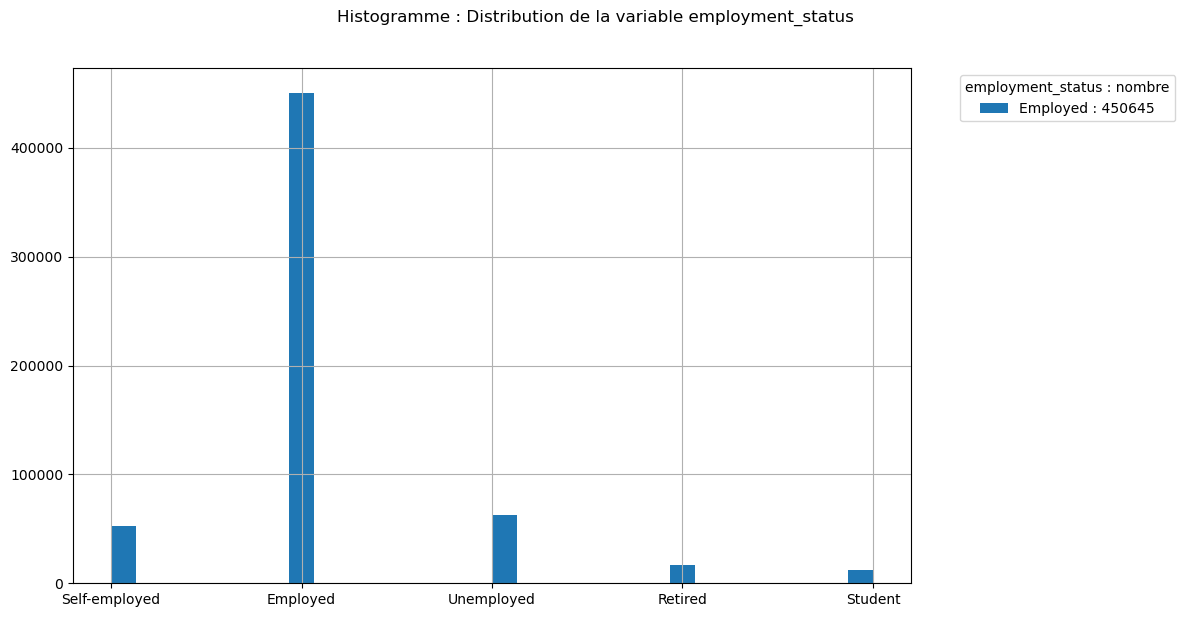

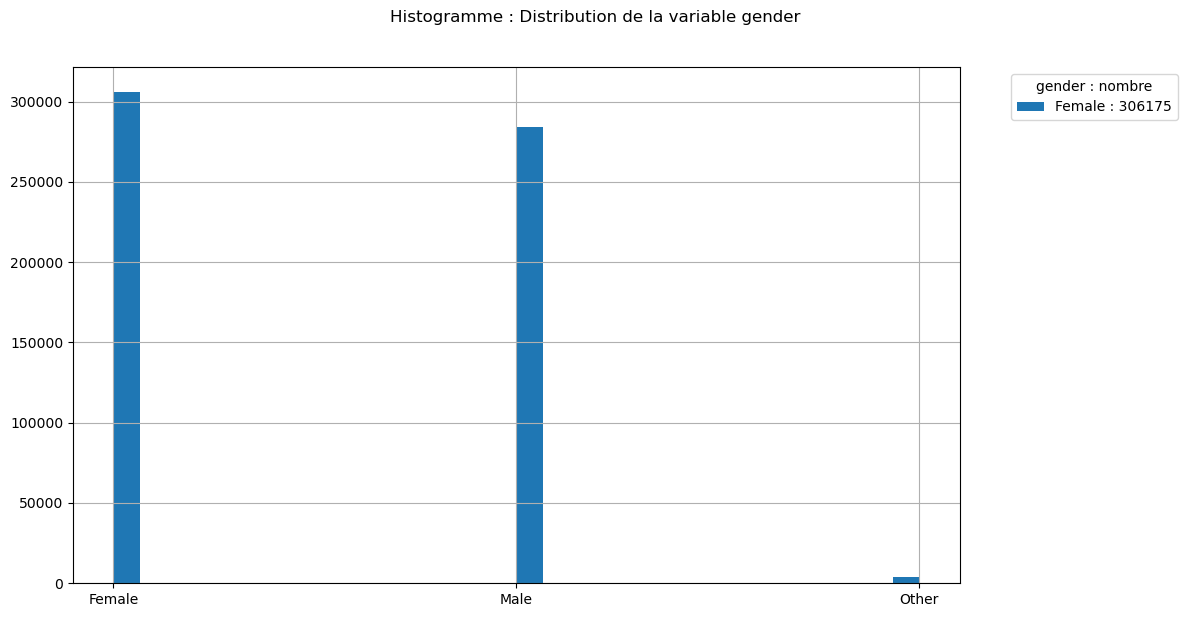

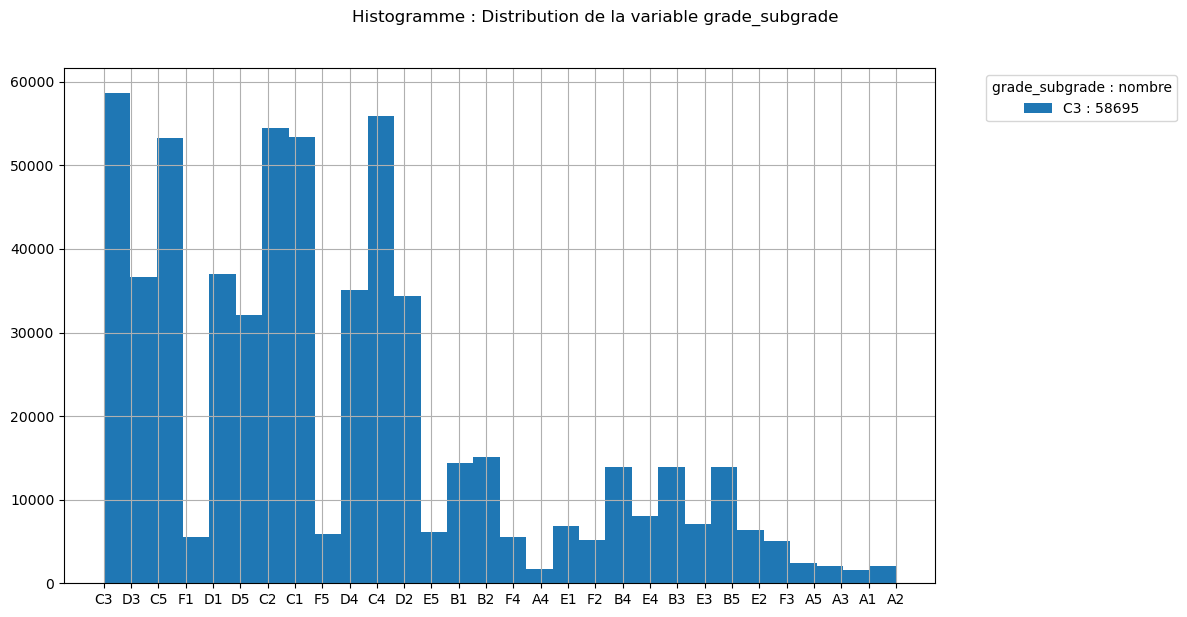

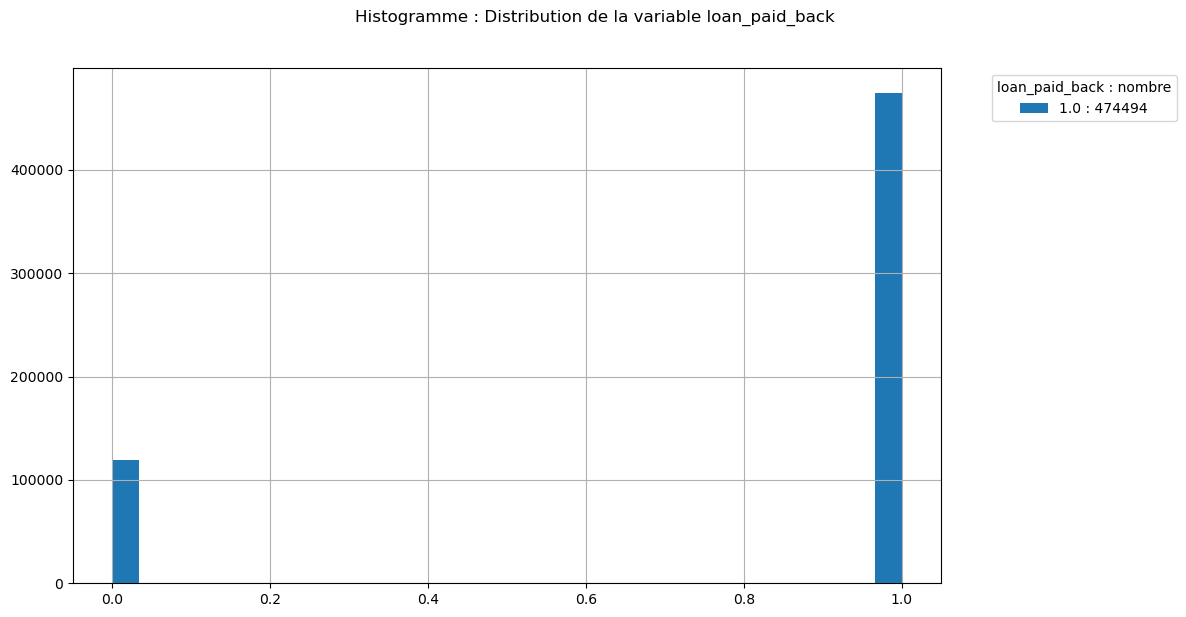

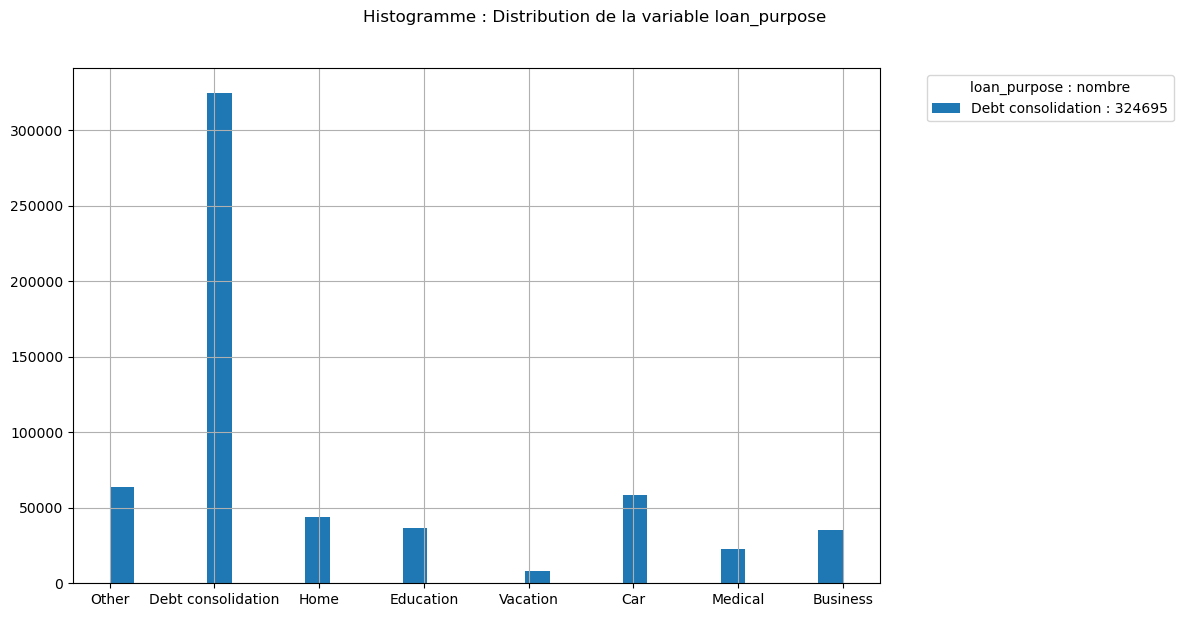

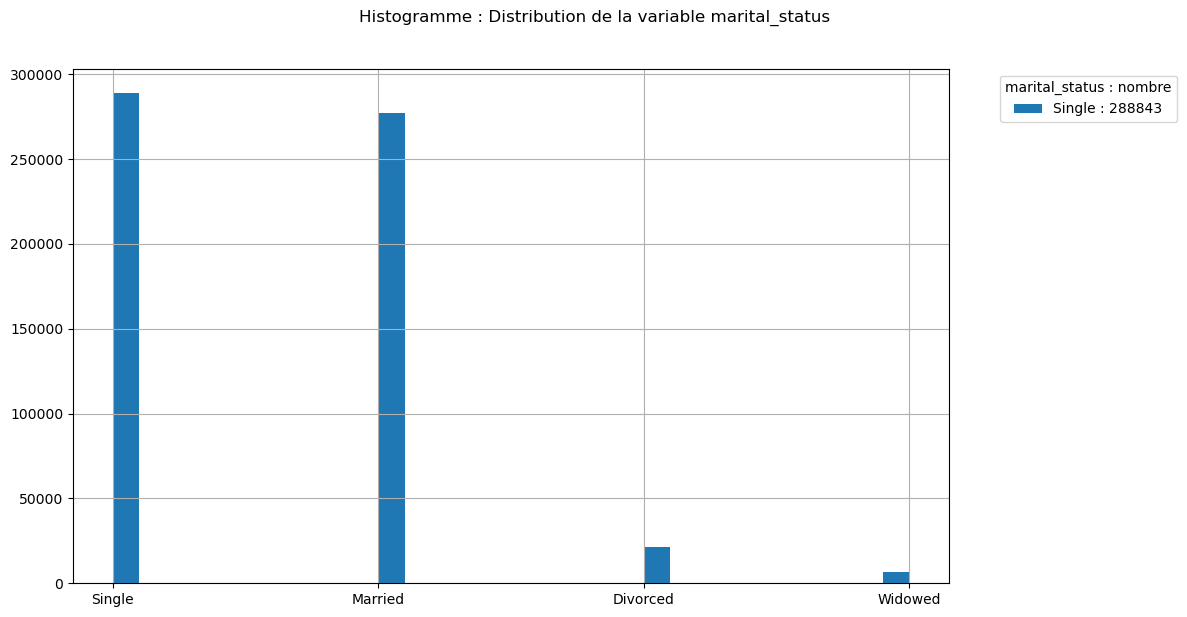

In [86]:
for colonne in colonnes_qualitatives:
    counts = train_data[colonne].value_counts()
    train_data[colonne].hist(bins=30, figsize = (12, 6))
    labels = [f'{val} : {cnt}' for val, cnt in counts.items()]
    plt.legend(labels, title= f'{colonne} : nombre', bbox_to_anchor=(1.05, 1),loc='upper left')
    plt.suptitle(f'Histogramme : Distribution de la variable {colonne}', y=1.02)
    plt.tight_layout()
    plt.show()

#### Ce qui ressort de ces observations
- on observe pour plusieurs variables qualitatives des valeurs très faiblement représentées
- en outre certaines variables ont des classes hiérarchisées

### Entraînement 1
 ici nous allons mettre utiliser un à trois algorithmes de prédiction sur nos données sans modifications complexes de celles ci
 nousn'effectuerons qu'un encodage pour les variables qualitatives

In [323]:
#algorithme de séparation des données
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

#algorithmes d'apprentissage
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMRegressor, LGBMClassifier

#algorithmes de pretraitement
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

# Évaluation
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    roc_auc_score,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Interprétabilité
from sklearn.inspection import permutation_importance
import shap

#### Encodage des variables categorielles
les variables catégorielles dans lesquelles il existe une relation d'ordre dans les valeurs
- education_level
- grade_subgrade

In [185]:
ordiEnc = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )
oneEnc = OneHotEncoder(
        sparse=False,
        handle_unknown='ignore'
    )

In [186]:
def encodageVariablesCategorielles(data, fit=False):

    orderVariables = ['education_level', 'grade_subgrade']
    non_orderVariables = ['employment_status', 'gender', 'loan_purpose', 'marital_status']

    # Ordinal encoding
    if fit:
        data[orderVariables] = ordiEnc.fit_transform(data[orderVariables])
    else:
        data[orderVariables] = ordiEnc.transform(data[orderVariables])

    # OneHot encoding
    if fit:
        variables_encodees = oneEnc.fit_transform(data[non_orderVariables])
    else:
        variables_encodees = oneEnc.transform(data[non_orderVariables])

    nouvelles_colonnes = oneEnc.get_feature_names_out(non_orderVariables)

    df_encoded = pd.DataFrame(
        variables_encodees,
        columns=nouvelles_colonnes,
        index=data.index
    )

    data = pd.concat(
        [data.drop(columns=non_orderVariables), df_encoded],
        axis=1
    )

    return data

In [334]:
#separation du jeu de donnees en apprentissage/test
X = train_data.drop(columns=['loan_paid_back', 'id'])
Y = train_data['loan_paid_back']
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, shuffle = True, stratify = Y, random_state = 42)

In [335]:
#apprentissage des encodeurs
encodedDataTrainCategoriel = encodageVariablesCategorielles(x_train, fit = True) 

In [336]:
encodedDataTestCategoriel = encodageVariablesCategorielles(x_test, fit = False)

In [306]:
encodedDataTrainCategoriel.head(5)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,education_level,grade_subgrade,employment_status_Employed,employment_status_Retired,employment_status_Self-employed,...,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed
100143,92432.16,0.067,636,14369.05,13.78,0.0,15.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
560097,28850.38,0.122,643,8471.26,14.40,1.0,19.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
356847,39427.43,0.041,672,7647.50,11.99,1.0,12.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
150444,71644.31,0.208,646,7125.57,12.19,1.0,17.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
550361,69010.47,0.186,708,10659.02,15.09,0.0,13.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


#### REGRESSION LOGISTIQUE

In [310]:
#regression logistique
rlo = LogisticRegression()
rlo.fit(encodedDataTrainCategoriel, y_train)

LogisticRegression()

In [311]:
y_pred_rloProba = rlo.predict_proba(encodedDataTestCategoriel)[:,1]
y_pred_rlo = rlo.predict(encodedDataTestCategoriel)

roc_rlo = roc_auc_score(y_test, y_pred_rloProba)
accuracy_rlo = accuracy_score(y_test, y_pred_rlo)
precision_rlo = precision_score(y_test, y_pred_rlo)
rappel_rlo = recall_score(y_test, y_pred_rlo)
f1_rlo = f1_score(y_test, y_pred_rlo)
print(roc_rlo, accuracy_rlo, precision_rlo, rappel_rlo, f1_rlo)

0.6770584551441853 0.7960420542260457 0.8015686743080508 0.9896732315409014 0.8857441952581248


#### RANDOM FOREST

In [337]:
#random forest classifier
rfc = RandomForestClassifier(n_estimators =300, max_depth =10, max_samples = 0.8, max_features='sqrt',
                           random_state = 42, n_jobs = -1)
rfc.fit(encodedDataTrainCategoriel, y_train)

RandomForestClassifier(max_depth=10, max_features='sqrt', max_samples=0.8,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [338]:
y_pred_rfcProba = rfc.predict_proba(encodedDataTestCategoriel)[:,1]
y_pred_rfc = rfc.predict(encodedDataTestCategoriel)

roc_rfc = roc_auc_score(y_test, y_pred_rfcProba)
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)
precision_rfc = precision_score(y_test, y_pred_rfc)
rappel_rfc = recall_score(y_test, y_pred_rfc)
f1_rfc = f1_score(y_test, y_pred_rfc)
print(roc_rfc, accuracy_rfc, precision_rfc, rappel_rfc, f1_rfc)

0.9104762711609582 0.9015648279867675 0.8992600696743731 0.9873865899535296 0.9412651056263749


#### XGBOOST

In [339]:
#Xgboost classifier
xgbc = XGBClassifier(n_estimators = 1000, max_depth = 5, early_stopping = 100, learning_rate = 0.03, subsample =0.8,
                    colsample_bytree=0.8, min_child_weight=3, gamma= 0.1, n_jobs=-1, random_state= 42)
xgbc.fit(encodedDataTrainCategoriel, y_train)

C:\Users\User\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [11:34:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "early_stopping" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping=100,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=0.1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [340]:
y_pred_xgbcProba = xgbc.predict_proba(encodedDataTestCategoriel)[:,1]
y_pred_xgbc = xgbc.predict(encodedDataTestCategoriel)

roc_xgbc = roc_auc_score(y_test, y_pred_xgbcProba)
accuracy_xgbc = accuracy_score(y_test, y_pred_xgbc)
precision_xgbc = precision_score(y_test, y_pred_xgbc)
rappel_xgbc = recall_score(y_test, y_pred_xgbc)
f1_xgbc = f1_score(y_test, y_pred_xgbc)
print(roc_xgbc, accuracy_xgbc, precision_xgbc, rappel_xgbc, f1_xgbc)

0.9199905230670035 0.9045193983114336 0.9069787830966158 0.981095691208548 0.9425824968489469


#### LIGHTGBM

In [260]:
lgbmr = LGBMRegressor(n_estimators = 1000, max_depth = 5, num_leaves=31, learning_rate = 0.03, subsample =0.8,
                    colsample_bytree=0.8, min_child_samples=3, n_jobs=-1, random_state= 42, verbose = -1)
lgbmr.fit(encodedDataTrainCategoriel, y_train)

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, max_depth=5,
              min_child_samples=3, n_estimators=1000, n_jobs=-1,
              random_state=42, subsample=0.8, verbose=-1)

In [261]:
y_pred_lgbm = lgbmr.predict(encodedDataTestCategoriel)
rmseLGBMR = np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
r2LGBMR = r2_score(y_test, y_pred_lgbm)
print(rmseLGBMR, r2LGBMR)

0.26894538440566423 0.5499153272301496


#### LGBMCLASSIFIER

In [341]:
lgbmc = LGBMClassifier(objective="binary",n_estimators = 1000, max_depth = 10, num_leaves=31, learning_rate = 0.03, subsample =0.8,
                    colsample_bytree=0.8, min_child_samples=3, n_jobs=-1, random_state= 42, verbose = -1)
lgbmc.fit(encodedDataTrainCategoriel, y_train)

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.03, max_depth=10,
               min_child_samples=3, n_estimators=1000, n_jobs=-1,
               objective='binary', random_state=42, subsample=0.8, verbose=-1)

In [342]:
y_pred_lgbmc = lgbmc.predict_proba(encodedDataTestCategoriel)[:,1]
roc = roc_auc_score(y_test, y_pred_lgbmc)
accuracy = accuracy_score(y_test, lgbmc.predict(encodedDataTestCategoriel))
precision = precision_score(y_test, lgbmc.predict(encodedDataTestCategoriel))
rappel = recall_score(y_test, lgbmc.predict(encodedDataTestCategoriel))
f1 = f1_score(y_test, lgbmc.predict(encodedDataTestCategoriel))
print(roc, accuracy, precision, rappel, f1)

0.920807740940699 0.9055800132997752 0.9084599164356281 0.9806109653421006 0.9431575746826463


In [343]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

scores = cross_validate(
    lgbmc,
    encodedDataTrainCategoriel,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

In [346]:
print(scores)

{'fit_time': array([131.52521086, 103.52908301, 133.79794049, 100.69166565,
        52.7838161 ]), 'score_time': array([12.60728192, 14.69868803, 12.60029674, 13.56970549,  4.81113219]), 'test_accuracy': array([0.90482854, 0.90535464, 0.90640684, 0.90550195, 0.9056703 ]), 'test_precision': array([0.908037  , 0.90801346, 0.90941188, 0.90924653, 0.9078085 ]), 'test_recall': array([0.98012355, 0.98088752, 0.98050554, 0.97946496, 0.98159881]), 'test_f1': array([0.94270421, 0.94304475, 0.94362153, 0.94305046, 0.94326273]), 'test_roc_auc': array([0.92054381, 0.921195  , 0.92061439, 0.92078866, 0.92191597])}


In [349]:
print(scores['test_roc_auc'].mean())

0.9210115663076497


### FEATURE INGENEERING
- creation de nouvelle variables et scaling pour tenter d'améliorer le modèle

In [326]:
#scaling des variables numeriques ayant une distribution asymétrique
tuned_data = train_data
tuned_data["log_income"] = np.log1p(tuned_data["annual_income"])
tuned_data["log_loan"] = np.log1p(tuned_data["loan_amount"])

In [327]:
#variable representant le pourcentage que le pret demandé represente par rapport au salaire annuel
tuned_data["loan_to_income"] = tuned_data["loan_amount"] / tuned_data["annual_income"]
#variable representant le coût annuel des intérets
tuned_data["annual_interest"] = (tuned_data["loan_amount"] * tuned_data["interest_rate"] / 100)
#variable representant le montant disponible apres le retraint des dettes
tuned_data["remaining_income"] = (tuned_data["annual_income"] *(1 - tuned_data["debt_to_income_ratio"]))
#variable mesurant la qualite du credit par rapport au montant emprunte
tuned_data["credit_per_loan"] = (tuned_data["credit_score"] /tuned_data["loan_amount"])
#variable mesurant la charge financière
tuned_data["interest_burden"] = (tuned_data["interest_rate"] *tuned_data["loan_amount"])
#variable mesurant l'indexe de risque
tuned_data["risk_index"] = (tuned_data["debt_to_income_ratio"] *tuned_data["interest_rate"])
#variable mesurant la'ajustement du credit par rapport au score de credit et au montant annuel
tuned_data["credit_income"] = (tuned_data["annual_income"] *tuned_data["credit_score"])
#variable mesurant le poids du financement par rapport au revenu.
tuned_data["loan_cost_ratio"] = (tuned_data["loan_amount"] *tuned_data["interest_rate"]) / tuned_data["annual_income"]

In [328]:
#split
#separation du jeu de donnees en apprentissage/test
X = tuned_data.drop(columns=['loan_paid_back', 'id'])
Y = tuned_data['loan_paid_back']
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, shuffle = True, stratify = Y, random_state = 42)

In [329]:
encodedDataTrainCategoriel = encodageVariablesCategorielles(x_train, fit = True) 
encodedDataTestCategoriel = encodageVariablesCategorielles(x_test, fit = False)

In [330]:
#regression logistique
rlo = LogisticRegression()
rlo.fit(encodedDataTrainCategoriel, y_train)
y_pred_rloProba = rlo.predict_proba(encodedDataTestCategoriel)[:,1]
y_pred_rlo = rlo.predict(encodedDataTestCategoriel)

roc_rlo = roc_auc_score(y_test, y_pred_rloProba)
accuracy_rlo = accuracy_score(y_test, y_pred_rlo)
precision_rlo = precision_score(y_test, y_pred_rlo)
rappel_rlo = recall_score(y_test, y_pred_rlo)
f1_rlo = f1_score(y_test, y_pred_rlo)
print(roc_rlo, accuracy_rlo, precision_rlo, rappel_rlo, f1_rlo)

0.7321004595019563 0.8085421594457866 0.8230506106952254 0.9685560437939282 0.8898947113639113


In [331]:
#random forest classifier
rfc = RandomForestClassifier(n_estimators =300, max_depth =10, max_samples = 0.8, max_features='sqrt',
                           random_state = 42, n_jobs = -1)
rfc.fit(encodedDataTrainCategoriel, y_train)
y_pred_rfcProba = rfc.predict_proba(encodedDataTestCategoriel)[:,1]
y_pred_rfc = rfc.predict(encodedDataTestCategoriel)

roc_rfc = roc_auc_score(y_test, y_pred_rfcProba)
accuracy_rfc = accuracy_score(y_test, y_pred_rfc)
precision_rfc = precision_score(y_test, y_pred_rfc)
rappel_rfc = recall_score(y_test, y_pred_rfc)
f1_rfc = f1_score(y_test, y_pred_rfc)
print(roc_rfc, accuracy_rfc, precision_rfc, rappel_rfc, f1_rfc)

0.9104762711609582 0.9015648279867675 0.8992600696743731 0.9873865899535296 0.9412651056263749


In [332]:
#Xgboost classifier
xgbc = XGBClassifier(n_estimators = 1000, max_depth = 5, early_stopping = 100, learning_rate = 0.03, subsample =0.8,
                    colsample_bytree=0.8, min_child_weight=3, gamma= 0.1, n_jobs=-1, random_state= 42)
xgbc.fit(encodedDataTrainCategoriel, y_train)
y_pred_xgbcProba = xgbc.predict_proba(encodedDataTestCategoriel)[:,1]
y_pred_xgbc = xgbc.predict(encodedDataTestCategoriel)

roc_xgbc = roc_auc_score(y_test, y_pred_xgbcProba)
accuracy_xgbc = accuracy_score(y_test, y_pred_xgbc)
precision_xgbc = precision_score(y_test, y_pred_xgbc)
rappel_xgbc = recall_score(y_test, y_pred_xgbc)
f1_xgbc = f1_score(y_test, y_pred_xgbc)
print(roc_xgbc, accuracy_xgbc, precision_xgbc, rappel_xgbc, f1_xgbc)

C:\Users\User\anaconda3\lib\site-packages\xgboost\core.py:158: UserWarning: [11:25:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "early_stopping" } are not used.

  warnings.warn(smsg, UserWarning)


0.9199905230670035 0.9045193983114336 0.9069787830966158 0.981095691208548 0.9425824968489469


In [333]:
lgbmc = LGBMClassifier(objective="binary",n_estimators = 1000, max_depth = 10, num_leaves=31, learning_rate = 0.03, subsample =0.8,
                    colsample_bytree=0.8, min_child_samples=3, n_jobs=-1, random_state= 42, verbose = -1)
lgbmc.fit(encodedDataTrainCategoriel, y_train)

y_pred_lgbmc = lgbmc.predict_proba(encodedDataTestCategoriel)[:,1]
roc = roc_auc_score(y_test, y_pred_lgbmc)
accuracy = accuracy_score(y_test, lgbmc.predict(encodedDataTestCategoriel))
precision = precision_score(y_test, lgbmc.predict(encodedDataTestCategoriel))
rappel = recall_score(y_test, lgbmc.predict(encodedDataTestCategoriel))
f1 = f1_score(y_test, lgbmc.predict(encodedDataTestCategoriel))
print(roc, accuracy, precision, rappel, f1)

0.920807740940699 0.9055800132997752 0.9084599164356281 0.9806109653421006 0.9431575746826463


### EXPLICABILITE DU MODELE
le model retenu ici est lightgbm classifier

#### FEATURE IMPORTANCE

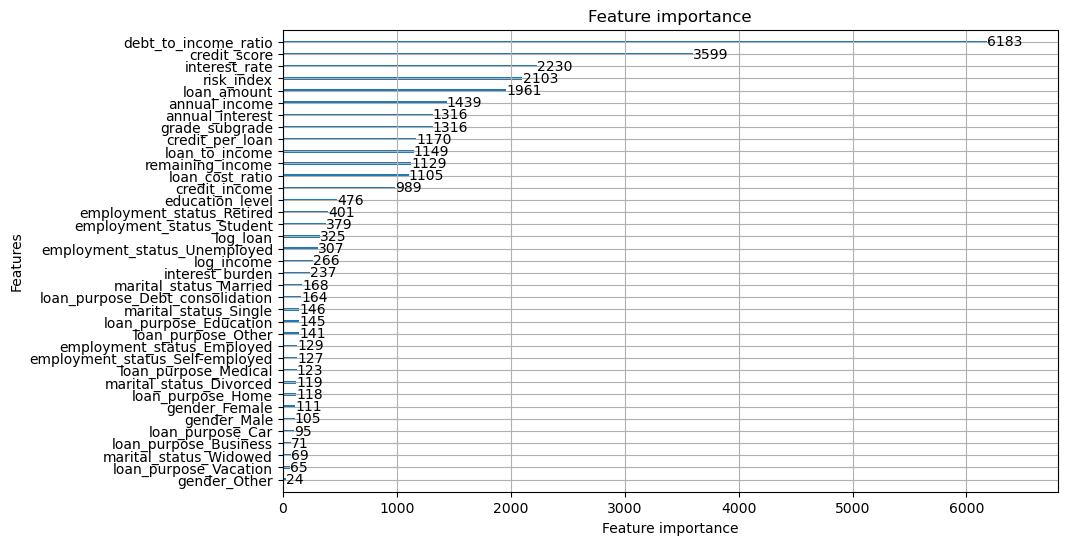

In [355]:
lgb.plot_importance(lgbmc, figsize=(10,6))
plt.show()

#### PERMUTATION IMPORTANCE

In [350]:
result = permutation_importance(
    lgbmc,
    encodedDataTestCategoriel,
    y_test,
    scoring='r2',
    n_repeats=2,
    random_state=42,
    n_jobs=-1
)

importance = pd.DataFrame({
    "Feature": encodedDataTestCategoriel.columns,
    "Importance": result.importances_mean
})

importance.sort_values("Importance", ascending=False)

,Feature,Importance
21,employment_status_Unemployed,0.708681
20,employment_status_Student,0.079589
1,debt_to_income_ratio,0.059109
2,credit_score,0.053478
3,loan_amount,0.020978
14,risk_index,0.020035
18,employment_status_Retired,0.014273
17,employment_status_Employed,0.014064
0,annual_income,0.013985
9,loan_to_income,0.013776


#### SHAP INFORMATIONS

In [ ]:
explainer = shap.TreeExplainer(lgbmc)
shap_values = explainer.shap_values(encodedDataTestCategoriel)
shap_values_default = shap_values[1] if isinstance(shap_values, list) else shap_values

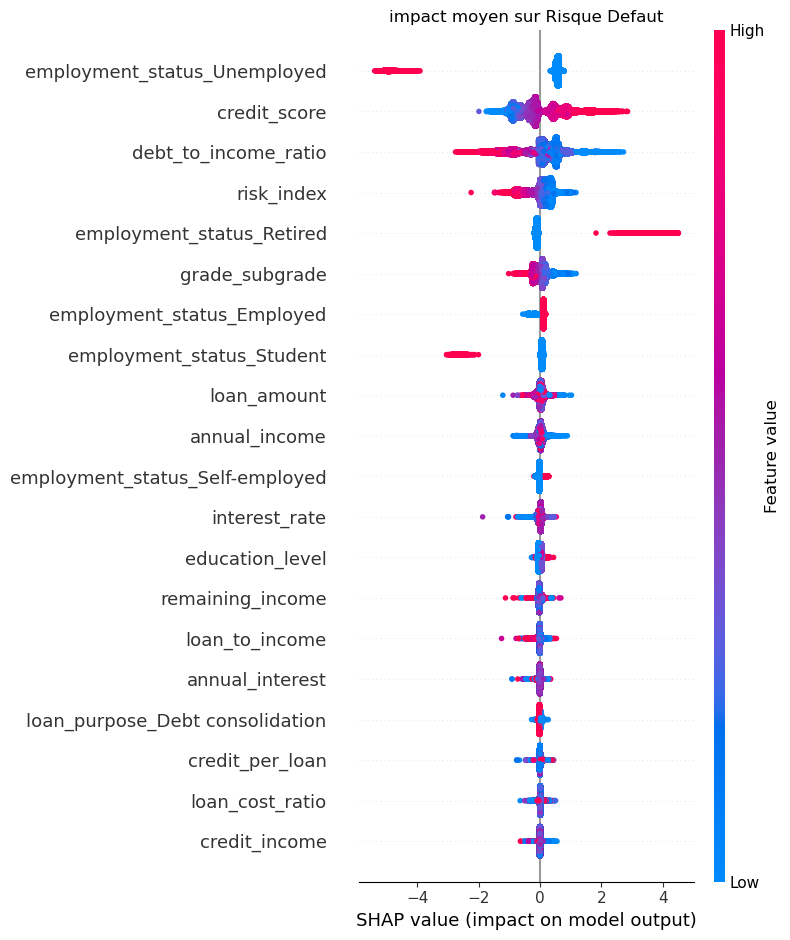

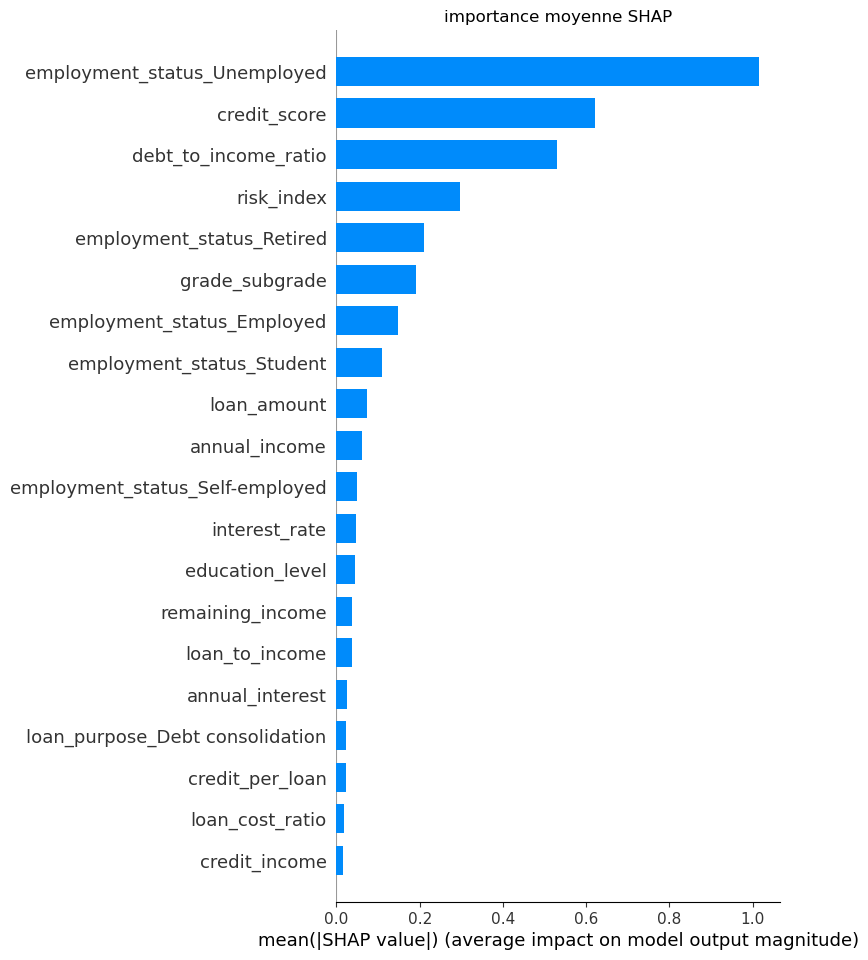

In [354]:
#plot global
shap.summary_plot(shap_values_default, encodedDataTestCategoriel, show = False)
plt.title('impact moyen sur Risque Defaut')
plt.tight_layout()
plt.show()
#plot bar
shap.summary_plot(shap_values_default, encodedDataTestCategoriel, plot_type='bar', show = False)
plt.title('importance moyenne SHAP')
plt.show()

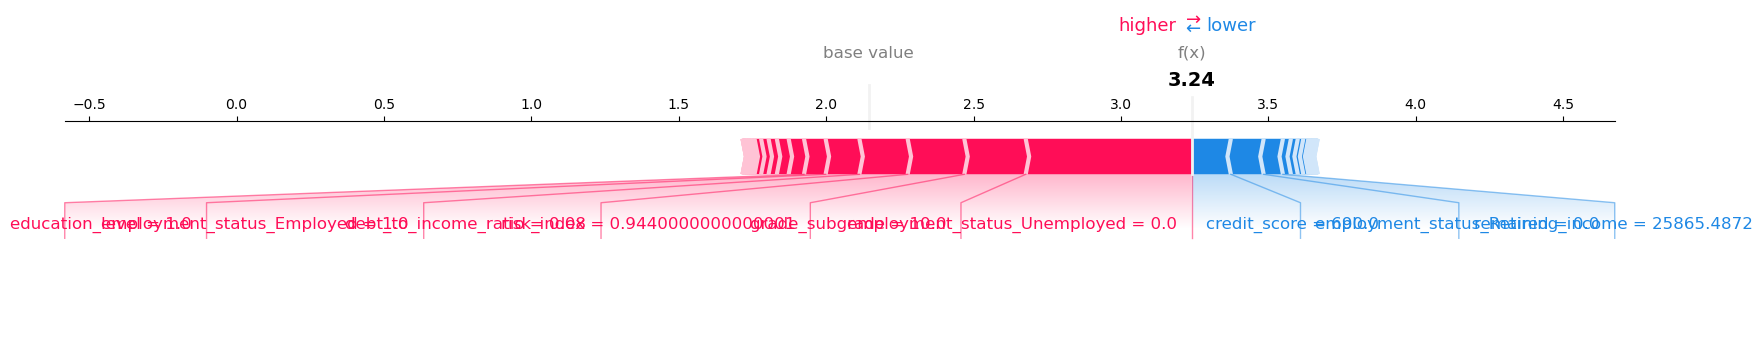

In [358]:
#plot local
shap.force_plot(explainer.expected_value, shap_values_default[0, :], encodedDataTestCategoriel.iloc[0, :], matplotlib = True)
plt.show()

In [406]:
test_sample = encodedDataTestCategoriel.iloc[6]
test_sample_obs = np.array(test_sample)

In [407]:
prediction = lgbmc.predict(test_sample_obs.reshape(1, -1))
prediction[0]

1.0

In [409]:
shap_single = shap_values[1, :]
interpretation = pd.DataFrame({
    'Variable': encodedDataTestCategoriel.columns,
    'Valeur_client': encodedDataTestCategoriel.iloc[1],
    'Shap_impact' : shap_single,
})
interpretation['Absolut_shap_impact'] = np.abs(interpretation['Shap_impact'])
interpretation.sort_values('Absolut_shap_impact', ascending=False)
interpretation

,Variable,Valeur_client,Shap_impact,Absolut_shap_impact
annual_income,annual_income,1.229337e+05,0.003573,0.003573
debt_to_income_ratio,debt_to_income_ratio,4.600000e-02,1.773101,1.773101
credit_score,credit_score,6.590000e+02,-0.184288,0.184288
loan_amount,loan_amount,7.268120e+03,-0.002548,0.002548
interest_rate,interest_rate,7.460000e+00,-0.166540,0.166540
education_level,education_level,1.000000e+00,-0.001198,0.001198
grade_subgrade,grade_subgrade,1.900000e+01,-0.380638,0.380638
log_income,log_income,1.171941e+01,0.069106,0.069106
log_loan,log_loan,8.891391e+00,0.027427,0.027427
loan_to_income,loan_to_income,5.912227e-02,-0.077975,0.077975


### SAUVEGARDE DU MODEL ET DU PIPELINE DE PRETRAITEMENT

In [437]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [440]:
preprocessor = ColumnTransformer(
    transformers=[
        ("ordinal", ordiEnc, orderVariables),
        ("onehot", oneEnc, non_orderVariables)
    ],
    remainder="passthrough"
)

In [443]:
loan_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LGBMClassifier(
        objective="binary",
        n_estimators=1000,
        max_depth=10,
        num_leaves=31,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=3,
        n_jobs=-1,
        random_state=42,
        verbose=-1
    ))
])

In [445]:
loan_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['education_level',
                                                   'grade_subgrade']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['employment_status',
                                                   'gender', 'loan_purpose',
                                                   'marital_status'])])),
                ('classifier',
                 LGBMClassifier(colsa

In [450]:
prediction = loan_pipeline.predict(x_test.iloc[[0]])
print(prediction)

[1.]


In [451]:
joblib.dump(loan_pipeline, 'loan_pipeline_lgbmClassifier.joblib')

['loan_pipeline_lgbmClassifier.joblib']

### SOUMISSION KAGGLE

In [200]:
#soumission
test_path = 'predict_loan_test.csv'
test_data = pd.read_csv(test_path)

In [201]:
encodingTestData = encodageVariablesCategorielles(test_data, fit = False)

In [298]:
y_test_pred = lgbmc.predict_proba(encodingTestData)[:, 1]
y_test_pred

array([0.93206428, 0.98249483, 0.39460352, ..., 0.91440073, 0.98609451,
       0.88178584])

In [299]:
soumission = pd.DataFrame({
    'id': test_data['id'],
    'loan_paid_back': y_test_pred
})
soumission.head()

,id,loan_paid_back
0,593994,0.932064
1,593995,0.982495
2,593996,0.394604
3,593997,0.934724
4,593998,0.944706


In [300]:
soumission.to_csv('soumission.csv', index=False)